# Notebook 04 — Continuous Market-State Analysis

## Objective

Construct a continuous settlement-period representation of
the GB Balancing Mechanism and investigate whether balancing
spreads exhibit:

- persistence,
- volatility clustering,
- stress regimes,
- and state-dependent behaviour through time.

Unlike earlier exploratory notebooks, this notebook explicitly
models the Balancing Mechanism as a continuous operational system
rather than a sparse collection of balancing events.

The notebook introduces:
- continuous settlement-period timelines,
- calm-state imputation,
- temporal market-state features,
- stress-regime identification,
- and exploratory stress-state classification.

The objective is not to build a production forecasting system,
but to determine whether balancing behaviour exhibits:
- persistent operational structure,
- or approximately memoryless dynamics.

Primary output:

- `continuous_market_state.parquet`

## 1. Load Core Datasets

This notebook combines:

| Dataset | Purpose |
|---|---|
| `modelling_dataset_enriched.parquet` | System prices, wind, and demand variables |
| `bm_actions.parquet` | Accepted balancing actions and prices |

These datasets are merged into a continuous
settlement-period state-space representation.

In [2]:
import pandas as pd
import numpy as np

# =========================================================
# LOAD CORE DATASETS
# =========================================================

df = pd.read_parquet(
    "../data/processed/modelling_dataset_enriched.parquet"
)

bm = pd.read_parquet(
    "../data/processed/bm_actions.parquet"
)

print(df.shape)

print(bm.shape)

(17524, 10)
(7085, 23)


## Motivation

Previous notebooks identified several important features
of balancing-market behaviour:

- balancing spreads appear highly state-dependent,
- volatility clusters through time,
- and stress events are not independently distributed.

However, earlier analysis remained partially event-driven
because balancing actions only occur intermittently.

This notebook therefore constructs a continuous
settlement-period market-state representation by:

- creating a canonical half-hourly timeline,
- merging balancing actions into all settlement periods,
- and explicitly modelling calm operational states.

This enables:
- persistence analysis,
- rolling volatility analysis,
- stress-state detection,
- and continuous-time market-state modelling.

## 2. Construct Operational Balancing Variables

Balancing actions are converted into operational variables
representing:

- accepted balancing volume,
- bid/offer direction,
- balancing price,
- and balancing action value.

Directionality is critically important in balancing markets:

- bids generally represent downward balancing actions,
- offers generally represent upward balancing actions.

Incorrect directional handling can materially distort
balancing-price aggregation and spread construction.

In [5]:
# =========================================================
# ACCEPTED MW
# =========================================================

bm['accepted_mw'] = (
    bm['level_to']
    - bm['level_from']
)

bm['accepted_mw_abs'] = (
    bm['accepted_mw'].abs()
)

# =========================================================
# DIRECTION FLAGS
# =========================================================

bm['is_bid'] = (
    bm['accepted_mw'] < 0
)

bm['is_offer'] = (
    bm['accepted_mw'] > 0
)

# =========================================================
# EFFECTIVE BM PRICE
# =========================================================

bm['bm_price'] = np.where(

    bm['is_bid'],

    bm['bid_price'],

    bm['offer_price']
)

# =========================================================
# ACTION VALUE
# =========================================================

bm['action_value'] = (
    bm['accepted_mw_abs']
    * bm['bm_price']
)

# =========================================================
# TIMESTAMP
# =========================================================

bm['settlement_date'] = pd.to_datetime(
    bm['settlement_date']
)

bm['timestamp'] = (
    bm['settlement_date']
    + pd.to_timedelta(
        (bm['settlement_period'] - 1) * 30,
        unit='m'
    )
)

print(bm.shape)

print(bm.columns)

(7085, 28)
Index(['dataset', 'settlement_date', 'settlement_period', 'settlementPeriodTo',
       'timeFrom', 'timeTo', 'level_from', 'level_to', 'acceptance_number',
       'acceptanceTime', 'deemedBoFlag', 'soFlag', 'amendmentFlag', 'storFlag',
       'rrFlag', 'bm_unit', 'bmUnit', 'constraint_group', 'timestamp',
       'bid_price', 'offer_price', 'accepted_mw', 'accepted_price',
       'accepted_mw_abs', 'is_bid', 'is_offer', 'bm_price', 'action_value'],
      dtype='object')


### Operational Pricing Note

Accepted balancing prices are directional:

- bid prices are associated with downward balancing,
- offer prices are associated with upward balancing.

The effective balancing price therefore depends on the
direction of accepted balancing action.

## 3. Create Canonical Settlement-Period Timeline

Balancing actions occur intermittently and therefore do not
naturally form a continuous time series.

To analyse persistence and market-state evolution,
a canonical half-hourly settlement-period timeline is created.

This ensures:
- continuous temporal coverage,
- stable rolling-window construction,
- and explicit representation of calm operational periods.

In [6]:
df['timestamp'] = pd.to_datetime(
    df['timestamp']
)

timeline = pd.DataFrame({

    'timestamp': pd.date_range(

        start=df['timestamp'].min(),

        end=df['timestamp'].max(),

        freq='30min'
    )
})

print(timeline.shape)

timeline.head()

(17520, 1)


,timestamp
0,2022-01-01 00:00:00
1,2022-01-01 00:30:00
2,2022-01-01 01:00:00
3,2022-01-01 01:30:00
4,2022-01-01 02:00:00


## 4. Aggregate Balancing Actions

Balancing actions are aggregated into settlement-period
market-state variables.

Key aggregated variables include:

| Variable | Description |
|---|---|
| `total_bid_mw` | Total downward balancing volume |
| `total_offer_mw` | Total upward balancing volume |
| `total_action_mw` | Total balancing activity |
| `net_action_mw` | Net balancing direction |
| `action_count` | Number of balancing acceptances |
| `total_action_value` | Aggregate balancing cost |

These variables provide a continuous operational
representation of balancing-market intensity.

In [7]:
bm_sp = bm.groupby('timestamp').agg(

    total_bid_mw=(
        'accepted_mw',
        lambda x: x[x < 0].abs().sum()
    ),

    total_offer_mw=(
        'accepted_mw',
        lambda x: x[x > 0].sum()
    ),

    total_action_mw=(
        'accepted_mw_abs',
        'sum'
    ),

    net_action_mw=(
        'accepted_mw',
        'sum'
    ),

    action_count=(
        'acceptance_number',
        'count'
    ),

    total_action_value=(
        'action_value',
        'sum'
    )

).reset_index()

### Balancing VWAP Construction

A settlement-period balancing VWAP is constructed using:

- accepted balancing prices,
- and accepted balancing volumes.

This provides an operational proxy for balancing-market pricing
within each settlement period.

The VWAP should be interpreted as:
- an aggregate operational balancing-price measure,
rather than:
- a directly tradable market price.

In [8]:
bm_sp['bm_price_vwap'] = (

    bm_sp['total_action_value']
    / bm_sp['total_action_mw']
)

In [9]:
market = timeline.merge(

    df,

    on='timestamp',

    how='left'
)

market = market.merge(

    bm_sp,

    on='timestamp',

    how='left'
)

print(market.shape)

(17526, 17)


5 — Fill calm-state values

In [10]:
fill_zero_cols = [

    'total_bid_mw',
    'total_offer_mw',
    'total_action_mw',
    'net_action_mw',
    'action_count',
    'total_action_value'
]

market[fill_zero_cols] = (
    market[fill_zero_cols]
    .fillna(0)
)

In [11]:
market['bm_price_vwap'] = (
    market['bm_price_vwap']
    .fillna(market['system_price'])
)

In [12]:
market['basis_spread'] = (

    market['system_price']
    - market['bm_price_vwap']
)

market['relative_spread'] = (

    market['basis_spread']
    / market['system_price']
)

6 — Temporal features

In [13]:
market = market.sort_values('timestamp')

market['spread_lag_1'] = (
    market['basis_spread'].shift(1)
)

market['spread_lag_48'] = (
    market['basis_spread'].shift(48)
)

market['spread_rolling_mean_4'] = (
    market['basis_spread']
    .rolling(4)
    .mean()
)

market['spread_volatility_12'] = (
    market['basis_spread']
    .rolling(12)
    .std()
)

market['wind_ramp_4'] = (
    market['wind_mw']
    - market['wind_mw'].shift(4)
)

## 5. Construct Continuous Market-State Frame

The canonical timeline is merged with:
- system-state variables,
- and aggregated balancing activity.

Periods with no balancing activity are explicitly retained.

This is important because:
- calm operational periods are economically meaningful,
- and excluding them would distort temporal persistence analysis.

7.1 Coverage diagnostics

In [14]:
print(market.shape)

print("\nMissing ratios:")

print(
    market[
        [
            'system_price',
            'bm_price_vwap',
            'basis_spread'
        ]
    ].isna().mean()
)

(17526, 23)

Missing ratios:
system_price     0.000514
bm_price_vwap    0.000514
basis_spread     0.000514
dtype: float64


7.2 Distribution diagnostics

In [ ]:
print(

    market[
        [
            'system_price',
            'bm_price_vwap',
            'basis_spread',
            'relative_spread'
        ]
    ].describe()
)

7.3 Time-series regime chart

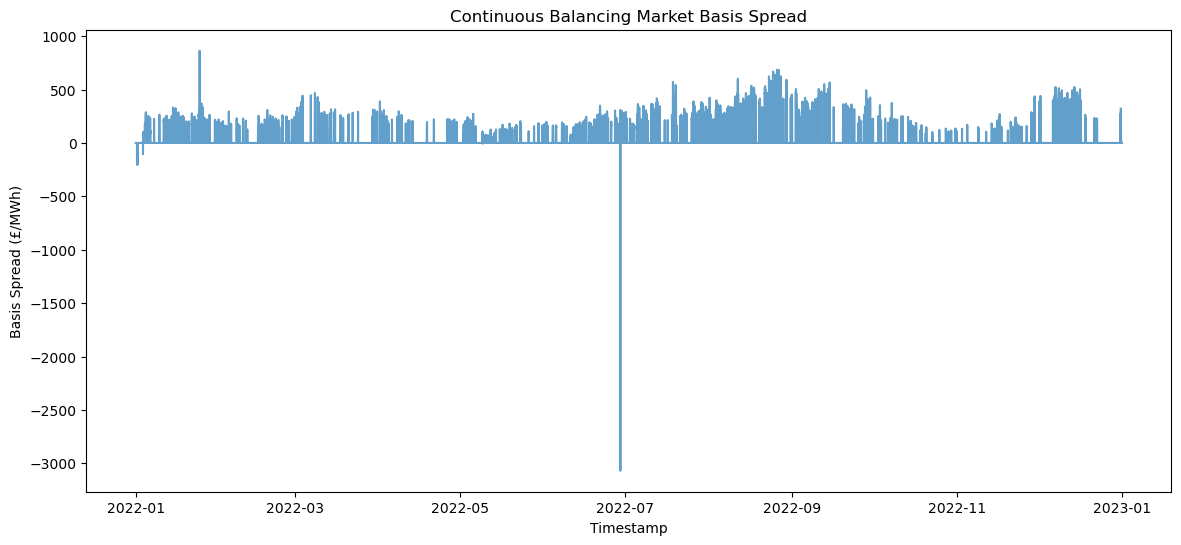

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread'],

    alpha=0.7
)

plt.title(
    "Continuous Balancing Market Basis Spread"
)

plt.xlabel("Timestamp")

plt.ylabel("Basis Spread (£/MWh)")

plt.show()

7.4 Wind regime analysis

In [16]:
market['wind_regime'] = pd.qcut(

    market['wind_mw'],

    q=4,

    labels=[
        'Low Wind',
        'Moderate Wind',
        'High Wind',
        'Very High Wind'
    ]
)

wind_regime = market.groupby(
    'wind_regime'
)['basis_spread'].mean()

print(wind_regime)

wind_regime
Low Wind          50.736450
Moderate Wind     43.860755
High Wind         28.878007
Very High Wind    13.048733
Name: basis_spread, dtype: float64


/tmp/ipykernel_3572/3681349034.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_regime = market.groupby(


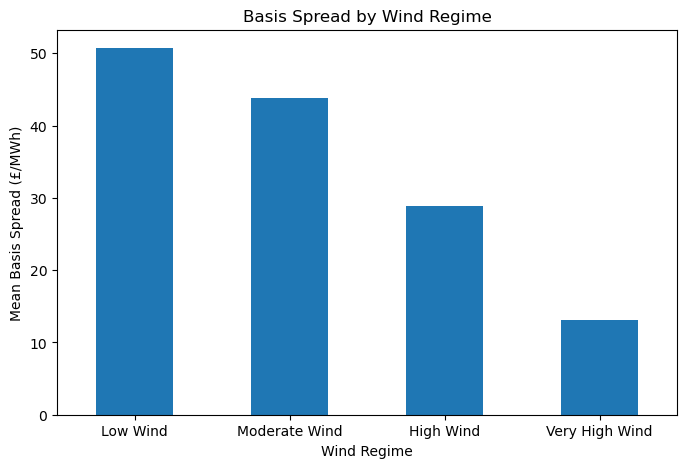

In [17]:
wind_regime.plot(

    kind='bar',

    figsize=(8,5)
)

plt.ylabel("Mean Basis Spread (£/MWh)")

plt.xlabel("Wind Regime")

plt.title("Basis Spread by Wind Regime")

plt.xticks(rotation=0)

plt.show()

7.5 Autocorrelation diagnostics

In [18]:
print(

    market[
        [
            'basis_spread',
            'spread_lag_1',
            'spread_lag_48'
        ]
    ].corr()
)

               basis_spread  spread_lag_1  spread_lag_48
basis_spread       1.000000      0.632950       0.231198
spread_lag_1       0.632950      1.000000       0.226573
spread_lag_48      0.231198      0.226573       1.000000


7.6 Stress regime chart

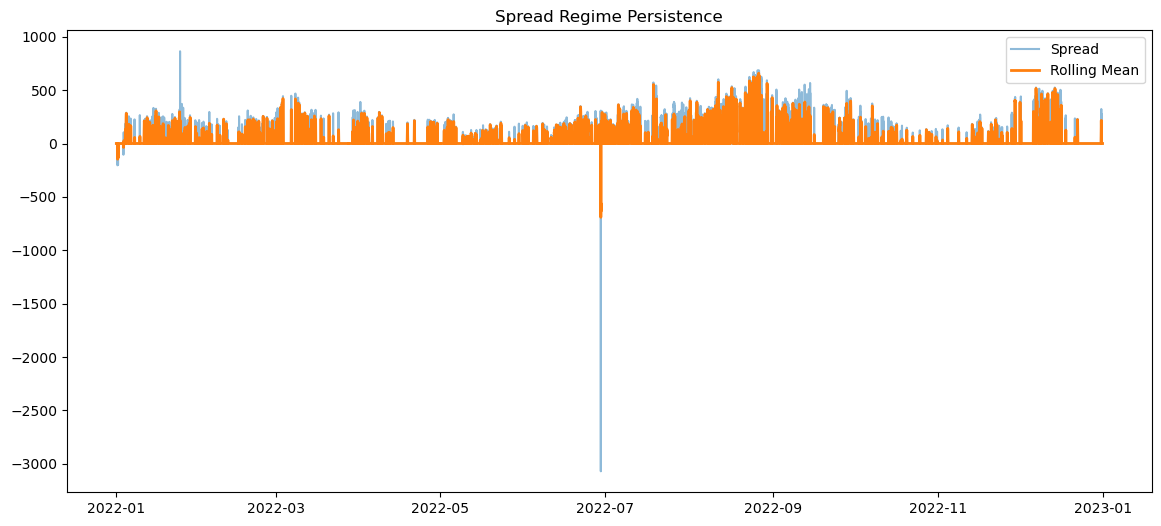

In [19]:
plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread'],

    alpha=0.5,

    label='Spread'
)

plt.plot(

    market['timestamp'],

    market['spread_rolling_mean_4'],

    linewidth=2,

    label='Rolling Mean'
)

plt.legend()

plt.title("Spread Regime Persistence")

plt.show()

## 7.7 Stress-Regime Detection

Stress periods are identified statistically using the upper
tail of observed balancing spreads.

Specifically:

```python
basis_spread > 95th percentile
```

This represents:
- a market-derived stress proxy,
rather than:
- an externally validated NESO operational stress classification.

In [20]:
market['stress'] = (
    market['basis_spread']
    > market['basis_spread'].quantile(0.95)
)

In [21]:
market.groupby('stress')[

    [
        'basis_spread',
        'wind_mw',
        'sw_demand_mw',
        'total_action_mw'
    ]

].mean()

,basis_spread,wind_mw,sw_demand_mw,total_action_mw
stress,,,,
False,15.417284,7464.652730,1335.601532,2.321542
True,389.961356,4387.395663,1479.174743,24.453714


7.8 — Stress event visualisation

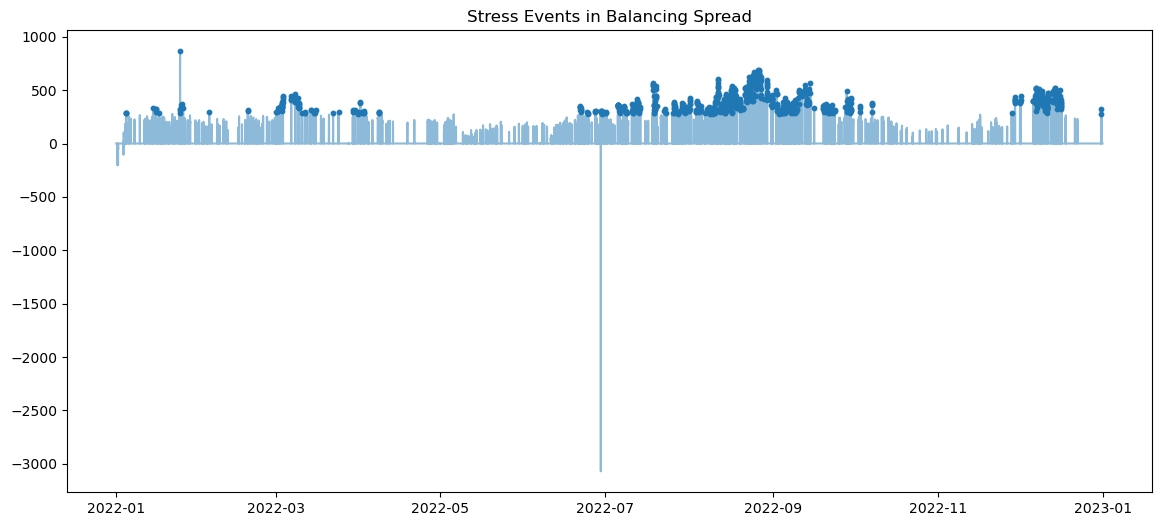

In [22]:
plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread'],

    alpha=0.5
)

stress_points = market[
    market['stress']
]

plt.scatter(

    stress_points['timestamp'],

    stress_points['basis_spread'],

    s=10
)

plt.title("Stress Events in Balancing Spread")

plt.show()

Stress periods are associated with:
- materially lower wind generation,
- elevated demand,
- and substantially higher balancing activity.

This suggests balancing stress is linked to renewable scarcity
and intensified system intervention.

## 6. Temporal Feature Engineering

Lagged and rolling features are constructed to test whether
balancing spreads exhibit:

- persistence,
- volatility clustering,
- and gradual market-state evolution.

Feature groups include:
- lagged spreads,
- rolling spread averages,
- rolling volatility,
- and renewable/demand ramp variables.

In [24]:
market['future_stress'] = (
    market['stress']
    .shift(-1)
)

market = market.dropna(
    subset=['future_stress']
)

market['future_stress'] = (
    market['future_stress']
    .astype(int)
)

8.1 Create modelling features

In [25]:
# =========================================================
# RAMP FEATURES
# =========================================================

market['wind_ramp_1'] = (
    market['wind_mw']
    - market['wind_mw'].shift(1)
)

market['wind_ramp_4'] = (
    market['wind_mw']
    - market['wind_mw'].shift(4)
)

market['demand_ramp_1'] = (
    market['sw_demand_mw']
    - market['sw_demand_mw'].shift(1)
)

market['demand_ramp_4'] = (
    market['sw_demand_mw']
    - market['sw_demand_mw'].shift(4)
)

# =========================================================
# VOLATILITY FEATURES
# =========================================================

market['spread_volatility_4'] = (
    market['basis_spread']
    .rolling(4)
    .std()
)

market['spread_volatility_12'] = (
    market['basis_spread']
    .rolling(12)
    .std()
)

8.2 Define feature set

In [26]:
features = [

    'wind_mw',
    'sw_demand_mw',

    'total_action_mw',
    'action_count',

    'spread_lag_1',
    'spread_lag_48',

    'spread_rolling_mean_4',
    'spread_volatility_4',
    'spread_volatility_12',

    'wind_ramp_1',
    'wind_ramp_4',

    'demand_ramp_1',
    'demand_ramp_4'
]

8.3 Build classifier dataset

In [27]:
clf_df = market[
    features + ['future_stress']
].dropna()

print(clf_df.shape)

print(
    clf_df['future_stress']
    .value_counts(normalize=True)
)

(17415, 14)
future_stress
0    0.949756
1    0.050244
Name: proportion, dtype: float64


### Persistence and Leakage Caveat

Many balancing-market variables exhibit strong temporal persistence,
including:
- balancing activity,
- spread volatility,
- and operational stress conditions.

As a result, some apparent predictive performance may reflect:
- recurring market states,
- volatility clustering,
- and same-regime continuation,

rather than fully independent forward-looking information.

The modelling sections in this notebook should therefore be interpreted
primarily as:
- stress-state persistence analysis,
rather than deployable forecasting systems.

8.4 Train/test split

In [28]:
split = int(len(clf_df) * 0.8)

train = clf_df.iloc[:split]

test = clf_df.iloc[split:]

X_train = train[features]

X_test = test[features]

y_train = train['future_stress']

y_test = test['future_stress']

8.5 Train Random Forest classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

clf = RandomForestClassifier(

    n_estimators=300,

    max_depth=6,

    min_samples_leaf=5,

    random_state=42,

    class_weight='balanced'
)

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3336
           1       0.54      0.80      0.65       147

    accuracy                           0.96      3483
   macro avg       0.77      0.88      0.81      3483
weighted avg       0.97      0.96      0.97      3483



8.6 Feature importance

In [30]:
importance = pd.Series(

    clf.feature_importances_,

    index=features

).sort_values(ascending=False)

print(importance)

spread_rolling_mean_4    0.233268
spread_volatility_4      0.162679
spread_volatility_12     0.124077
total_action_mw          0.120262
action_count             0.092852
spread_lag_1             0.081617
spread_lag_48            0.049589
wind_mw                  0.033607
demand_ramp_4            0.033090
demand_ramp_1            0.030051
sw_demand_mw             0.017414
wind_ramp_1              0.010953
wind_ramp_4              0.010540
dtype: float64


8.7 Plot feature importance

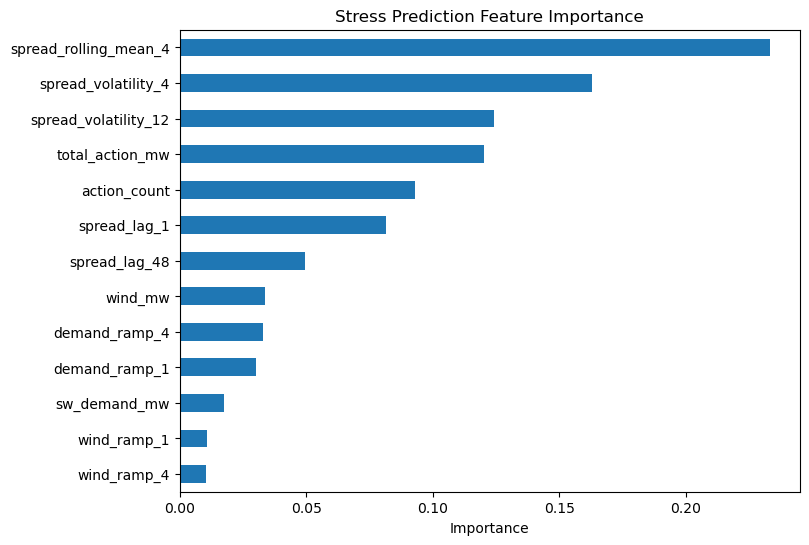

In [31]:
import matplotlib.pyplot as plt

importance.sort_values().plot(

    kind='barh',

    figsize=(8,6)
)

plt.title(
    "Stress Prediction Feature Importance"
)

plt.xlabel("Importance")

plt.show()

An extreme negative spread event (~£-3000/MWh) was observed on
29 June 2022.

Inspection showed this was driven by a very small balancing volume
(18 MW) accepted at an exceptionally high BM offer price (~£3333/MWh).

This appears economically plausible rather than a data error,
but it strongly distorts visualisation and volatility metrics.

To preserve statistical integrity while improving interpretability,
subsequent analysis uses both:
- raw spreads for stress-event analysis,
- and clipped/filtered spreads for modelling robustness.

### Stress-Regime Interpretation

Stress periods are associated with:
- materially larger balancing spreads,
- lower wind generation,
- elevated demand,
- and substantially higher balancing activity.

This suggests balancing stress is linked to:
- renewable scarcity,
- increased operational intervention,
- and intensified balancing requirements.

## 7. Continuous Market-State Exploration

This section investigates whether balancing spreads exhibit:

- temporal persistence,
- volatility clustering,
- stress-state asymmetry,
- and regime-dependent behaviour.

The objective is to determine whether balancing spreads behave:
- independently through time,
or instead:
- evolve continuously across persistent operational states.

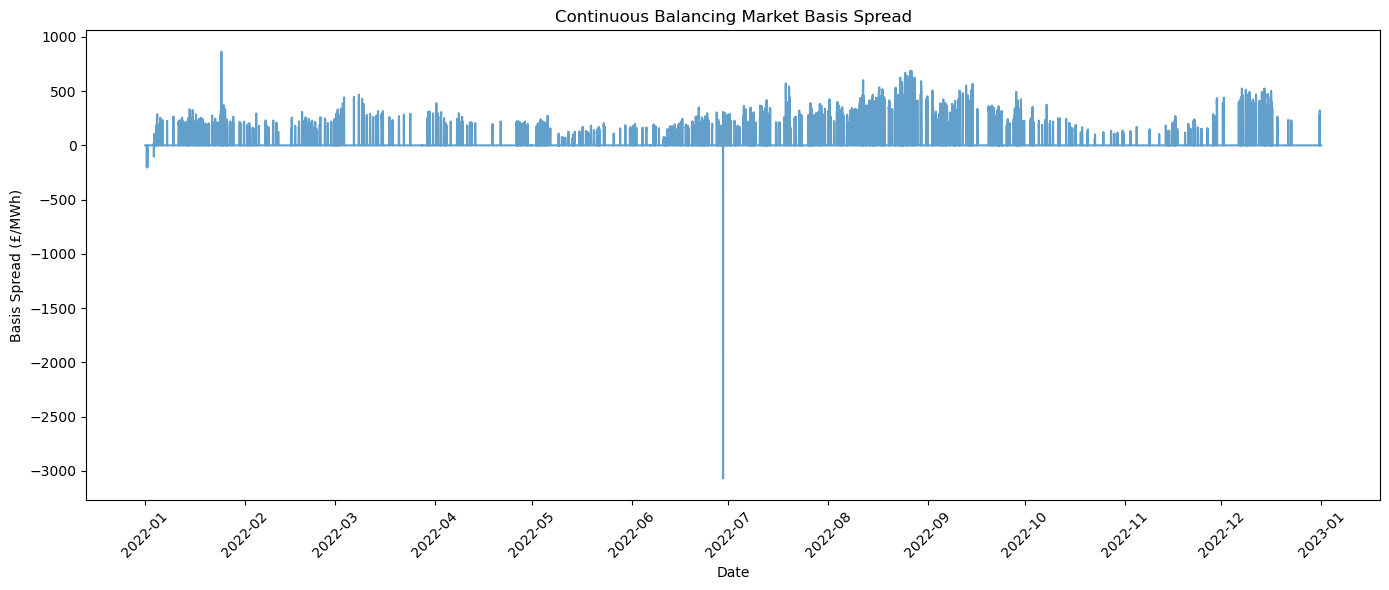

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread'],

    alpha=0.7
)

plt.title(
    "Continuous Balancing Market Basis Spread"
)

plt.xlabel("Date")

plt.ylabel("Basis Spread (£/MWh)")

# =========================================================
# MONTHLY TICKS
# =========================================================

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [42]:
market['basis_spread_clipped'] = (
    market['basis_spread']
    .clip(-500, 500)
)

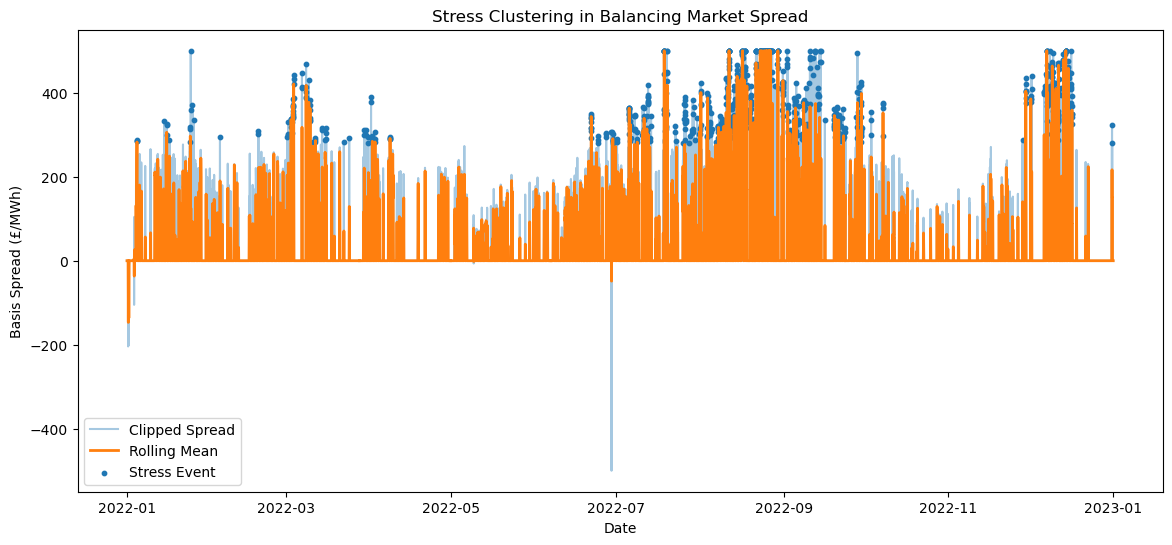

In [47]:
plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread_clipped'],

    alpha=0.4,

    label='Clipped Spread'
)

plt.plot(

    market['timestamp'],

    market['basis_spread_clipped']
    .rolling(4)
    .mean(),

    linewidth=2,

    label='Rolling Mean'
)

stress_points = market[
    market['stress']
]

plt.scatter(

    stress_points['timestamp'],

    stress_points['basis_spread_clipped'],

    s=10,

    label='Stress Event'
)

plt.title(
    "Stress Clustering in Balancing Market Spread"
)

plt.xlabel("Date")

plt.ylabel("Basis Spread (£/MWh)")

plt.legend()

plt.show()

Low-volume filter

In [49]:
market['basis_spread_filtered'] = np.where(

    market['total_action_mw'] >= 50,

    market['basis_spread'],

    np.nan
)

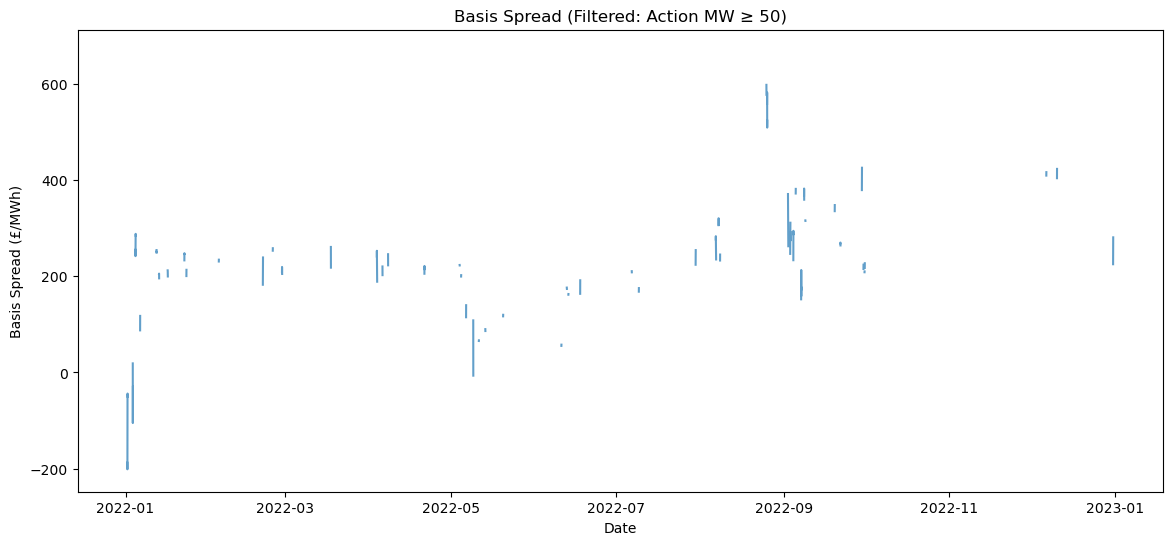

In [50]:
plt.figure(figsize=(14,6))

plt.plot(

    market['timestamp'],

    market['basis_spread_filtered'],

    alpha=0.7
)

plt.title(
    "Basis Spread (Filtered: Action MW ≥ 50)"
)

plt.xlabel("Date")

plt.ylabel("Basis Spread (£/MWh)")

plt.show()

In [51]:
market['spread_smooth_24'] = (

    market['basis_spread_clipped']
    .rolling(24)
    .mean()
)

## 8. Continuous-Time Stress-State Modelling

An exploratory classification framework is constructed
to test whether future stress states exhibit detectable
temporal structure.

The objective is not high-frequency forecasting,
but rather evaluation of whether balancing stress behaves:
- independently,
or:
- as a persistent evolving operational regime.

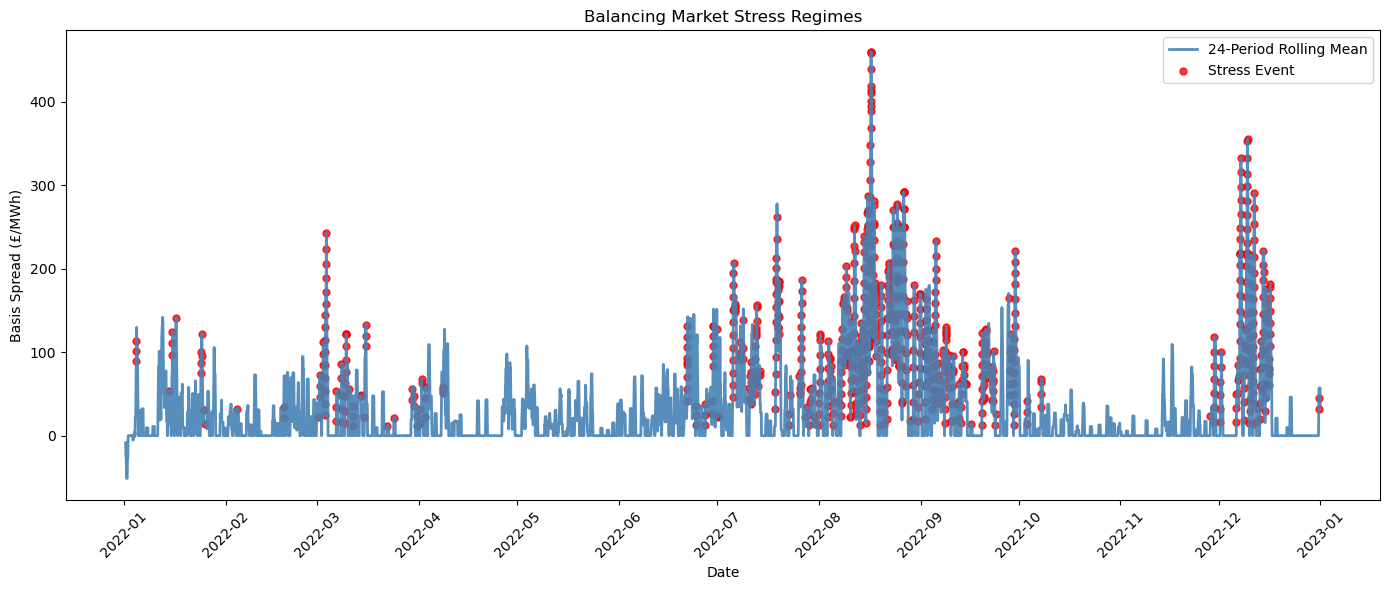

In [58]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =========================================================
# SMOOTHED SPREAD
# =========================================================

market['spread_smooth_24'] = (

    market['basis_spread_clipped']
    .rolling(24)
    .mean()
)

# =========================================================
# STRESS POINTS
# =========================================================

stress_points = market[
    market['stress']
]

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(14,6))

# Rolling mean line
plt.plot(

    market['timestamp'],

    market['spread_smooth_24'],

    linewidth=2,

    alpha=0.9,

    color='steelblue',

    label='24-Period Rolling Mean'
)

# Stress markers
plt.scatter(

    stress_points['timestamp'],

    stress_points['spread_smooth_24'],

    s=25,

    color='red',

    marker='o',

    alpha=0.8,

    label='Stress Event'
)

# =========================================================
# FORMATTING
# =========================================================

plt.title(
    "Balancing Market Stress Regimes"
)

plt.xlabel("Date")

plt.ylabel("Basis Spread (£/MWh)")

plt.gca().xaxis.set_major_locator(
    mdates.MonthLocator()
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m')
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

The smoothed spread series reveals persistent market-state regimes
rather than isolated pricing shocks.

Stress conditions cluster strongly during August–September 2022
and re-emerge in December, while April–June and October–November
appear comparatively stable.

This temporal structure aligns with the observed autocorrelation,
volatility persistence, and successful stress-state prediction results.

The observed stress behaviour does not necessarily imply market dysfunction.

Instead, the Balancing Mechanism appears to respond dynamically
to periods of operational scarcity by increasing balancing prices,
activity intensity, and spread volatility.

This suggests balancing spreads may act as a market-based indicator
of latent system stress and flexibility scarcity.

### Extreme-Spread Asymmetry

Extreme balancing spreads are operationally asymmetric.

Large positive spreads are typically associated with:
- curtailment,
- downward balancing,
- and bid-driven redispatch behaviour.

Large negative spreads instead reflect scarcity conditions,
where expensive BM offers are accepted to increase generation
or demand-side response.

These scarcity-driven events may therefore represent
a distinct operational regime rather than simple statistical outliers.

### Classification Interpretation

Overall classification accuracy is inflated by:
- strong class imbalance,
- stress persistence,
- and recurring operational regimes.

Minority-class precision and recall therefore provide
a more informative assessment of stress-detection performance
than headline accuracy alone.

The results suggest balancing stress exhibits:
- persistence,
- temporal clustering,
- and partially predictable operational structure.

### Feature Importance Interpretation

Rolling spread statistics dominate feature importance.

This likely reflects:
- regime persistence,
- volatility clustering,
- and market-state continuity,

rather than stable causal relationships.

Feature importance should therefore be interpreted as:
- descriptive of operational state structure,
rather than:
- evidence of robust causal forecasting power.

# Notebook Summary

This notebook transformed balancing-market analysis from:
- sparse event-based exploration,
toward:
- continuous market-state modelling.

Key findings included:
- strong spread persistence,
- volatility clustering,
- stress-regime behaviour,
- and substantial temporal market-state continuity.

Stress periods were associated with:
- lower wind generation,
- elevated demand,
- and materially higher balancing activity.

Importantly, balancing stress appeared to cluster through time
rather than occur as isolated independent events.

However, the notebook also identified important methodological limitations:

- balancing variables exhibit substantial persistence,
- some features partially encode current market state,
- and predictive performance may overstate genuinely forward-looking information.

These findings motivated the later adaptive-equilibrium framework,
where apparent disequilibrium is evaluated under explicitly
time-evolving market conditions.

In [59]:
market.to_parquet(

    "../data/processed/continuous_market_state.parquet",

    index=False
)

print("Saved continuous_market_state.parquet")

Saved continuous_market_state.parquet
